# Calculation of upper and lower envelope variables

The upper and lower envelope variables describe the maximum and minimum values of a time-varying signal (such as a joint angle, force, or marker trajectory) over a specific period, typically a gait cycle.
The upper envelope traces the local maxima, while the lower envelope traces the local minima of the signal. These envelopes are useful for quantifying the range and variability of biomechanical signals, identifying outliers, and comparing movement patterns across subjects or conditions.

## Calculating upper and lower envelope for Joint angles:

We will find the peaks and troughs of normalized joint angle time series and will interpolate them to get a smooth envelope.
point-value metrics can be calculated from the envelope. i.e. the maximum, minimum, mean, etc...

In [1]:
from core.matlab_data_loader import MatlabDataLoader
import kineticstoolkit as ktk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, envelope, hilbert
from scipy.interpolate import interp1d

In [2]:
loader = MatlabDataLoader()

first_session_id = loader.get_successful_sessions()[0]
print("First session id: ", first_session_id)

L_KNEE_MARKER = "L_shank_1"
L_KNEE_JOINT = "L_knee"

# Raw
l_shank_1_marker_data = loader.get_marker_data(first_session_id, L_KNEE_MARKER)
l_knee_angle_data = loader.get_joint_angles(first_session_id, L_KNEE_JOINT, normalized=False)
l_knee_velocity_data = loader.get_joint_velocities(first_session_id, L_KNEE_JOINT, normalized=False)

# Normalisedb
l_knee_normalized_angle_data = loader.get_joint_angles(first_session_id, L_KNEE_JOINT, normalized=True)
l_knee_normalized_velocity_data = loader.get_joint_velocities(first_session_id, L_KNEE_JOINT, normalized=True)

First session id:  100001_20110531T161051


In [3]:
print("L_knee normalized Angle data shape:", l_knee_normalized_angle_data.shape)
print("\nFirst few rows:")
print(l_knee_normalized_angle_data.head())
print("\nData info:")
print(l_knee_normalized_angle_data.info())

print("\nL_knee angle data shape:", l_knee_angle_data.shape)
print("\nFirst few rows:")
print(l_knee_angle_data.head())
print("\nData info:")
print(l_knee_angle_data.info())

L_knee normalized Angle data shape: (101, 4)

First few rows:
   PercentGaitCycle     X_deg     Y_deg     Z_deg
0          0.990099 -3.318307 -3.991331 -3.602910
1          1.980198 -3.446051 -4.141391 -3.720143
2          2.970297 -3.574228 -4.297134 -3.838855
3          3.960396 -3.702452 -4.458029 -3.958587
4          4.950495 -3.827711 -4.618412 -4.073492

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PercentGaitCycle  101 non-null    float64
 1   X_deg             101 non-null    float64
 2   Y_deg             101 non-null    float64
 3   Z_deg             101 non-null    float64
dtypes: float64(4)
memory usage: 3.3 KB
None

L_knee angle data shape: (4000, 4)

First few rows:
   TimeIndex      X_deg     Y_deg      Z_deg
0          1  -8.981527 -7.752238  20.139146
1          2  -9.485651 -7.734218  22.084077
2      

In [4]:
print("Gait events:")
events = loader.get_gait_events(first_session_id)
print("\nShape:")
print(events.shape)
print("\nFirst few rows:")
display(events.head())
print("\nData info:")
print(events.info())

Gait events:

Shape:
(22, 9)

First few rows:


,EventNumber,L_TD,L_Midstance,L_TO,L_heelwhip,R_TD,R_Midstance,R_TO,R_heelwhip
0,1,235,267,299,323.0,309,344,378,409.0
1,2,386,418,450,475.0,459,493,526,565.0
2,3,536,568,599,626.0,609,644,678,717.0
3,4,688,720,751,781.0,762,796,829,869.0
4,5,840,873,905,931.0,914,948,981,1011.0



Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   EventNumber  22 non-null     int64  
 1   L_TD         22 non-null     int64  
 2   L_Midstance  22 non-null     int64  
 3   L_TO         22 non-null     int64  
 4   L_heelwhip   21 non-null     float64
 5   R_TD         22 non-null     int64  
 6   R_Midstance  22 non-null     int64  
 7   R_TO         22 non-null     int64  
 8   R_heelwhip   21 non-null     float64
dtypes: float64(2), int64(7)
memory usage: 1.7 KB
None


In [5]:
l_touchdown_events = events["L_TD"].to_list()
l_toe_off_events = events["L_TO"].to_list()
r_touchdown_events = events["R_TD"].to_list()
r_toe_off_events = events["R_TO"].to_list()

ts = ktk.TimeSeries()
ts.time = l_knee_angle_data["TimeIndex"]
ts = ts.add_data("l_knee_angle", l_knee_angle_data.values[:, 1:])
ts

TimeSeries with attributes:
         time: array([ 1, 2, 3, ..., 3998, 3999, 4000])
         data: <dict with 1 entries>
    time_info: {'Unit': 's'}
    data_info: {}
       events: []

In [6]:
for event in l_touchdown_events:
    ts = ts.add_event(event, "L_TD")

for event in l_toe_off_events:
    ts = ts.add_event(event, "L_TO")

ts

TimeSeries with attributes:
         time: array([ 1, 2, 3, ..., 3998, 3999, 4000])
         data: <dict with 1 entries>
    time_info: {'Unit': 's'}
    data_info: {}
       events: <list of 44 items>

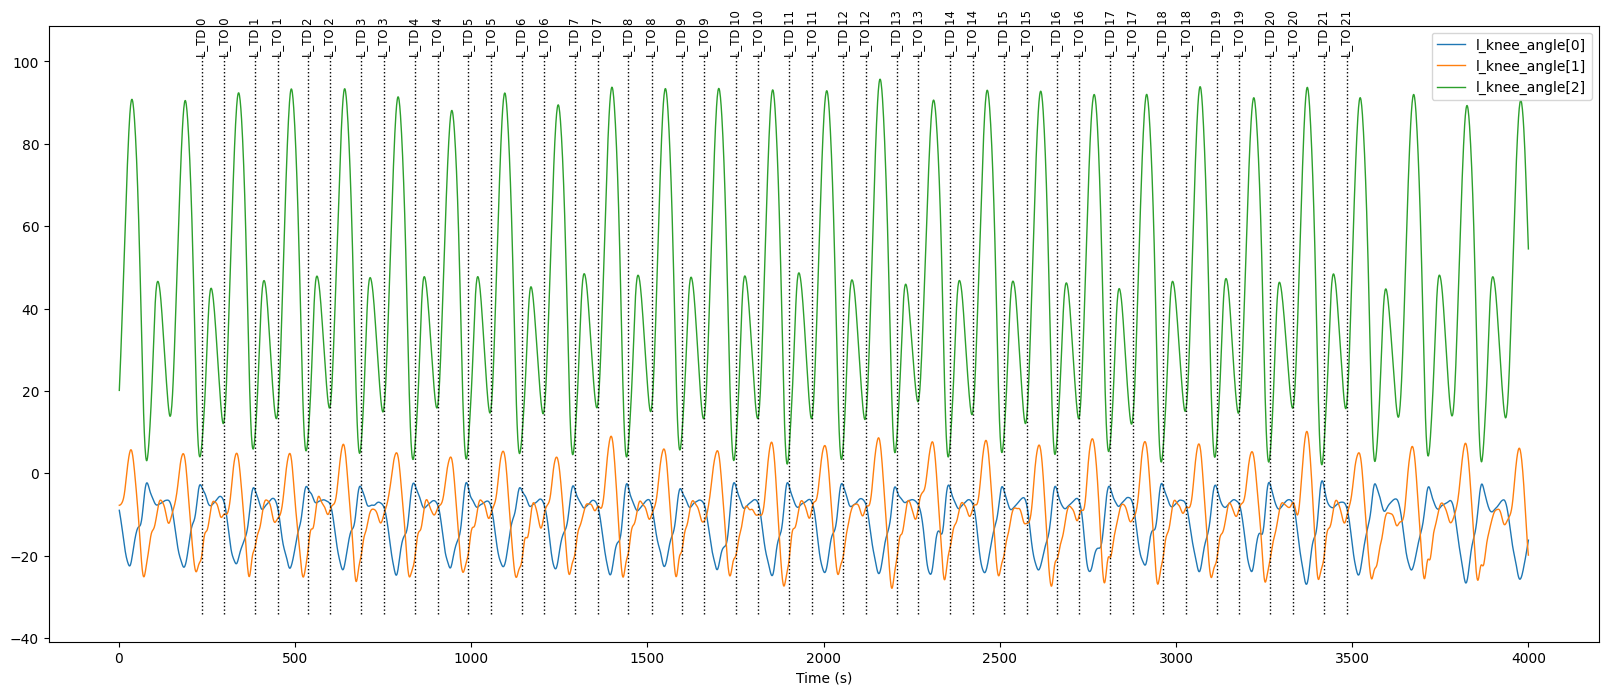

In [7]:
plt.figure(figsize=(20, 8))
ts.plot()

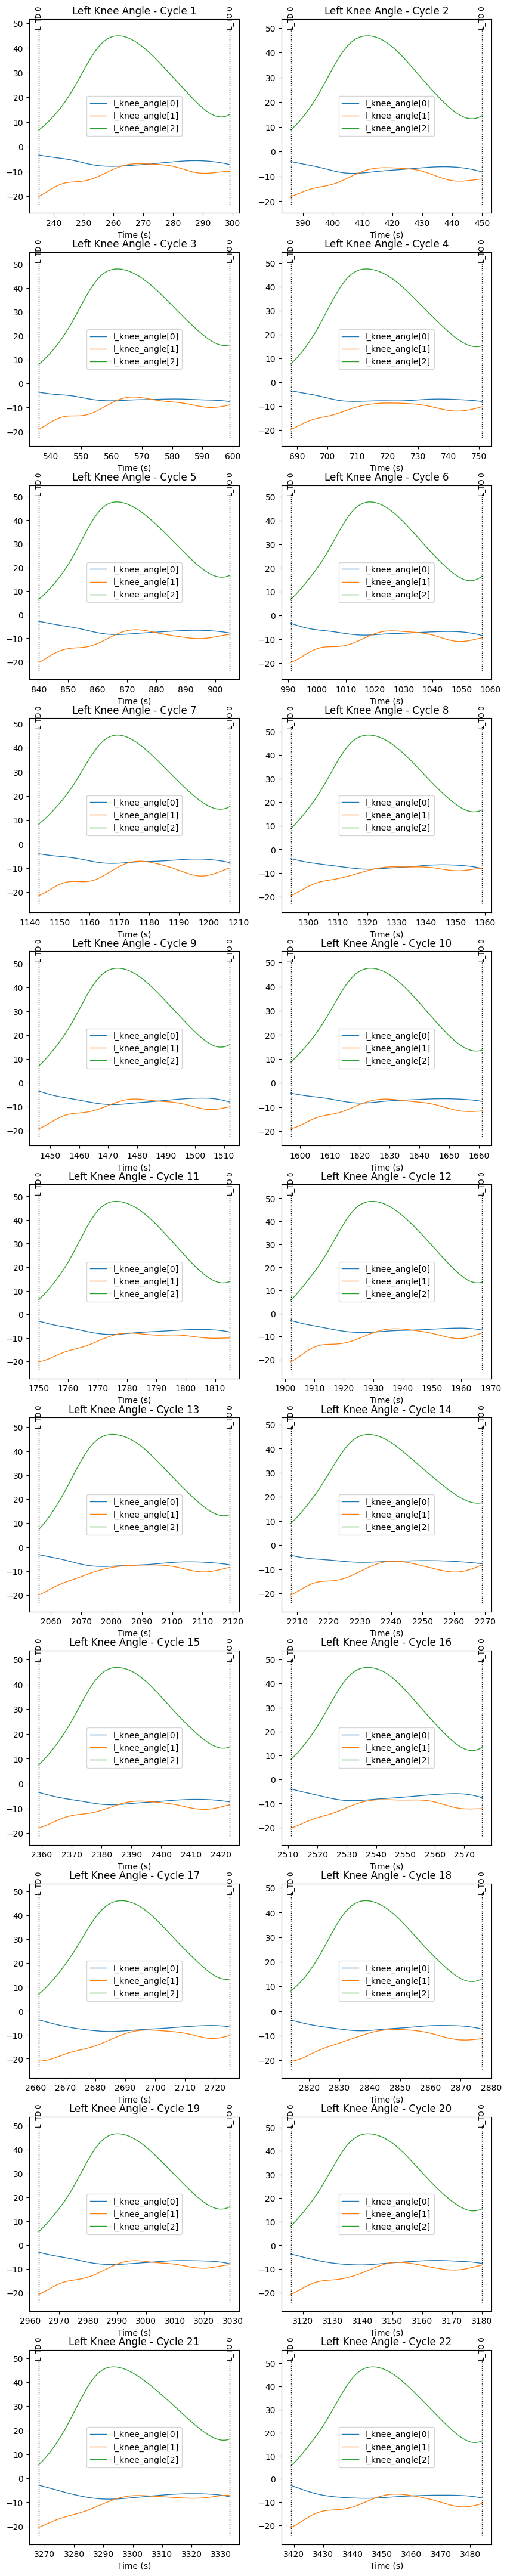

In [28]:
max_cycles = len(l_touchdown_events)

ncols = 2
nrows = (max_cycles + ncols - 1) // ncols


plt.figure(figsize=(10, 5 * nrows))
for i in range(max_cycles):
    cycle = ts.get_ts_between_events("L_TD", "L_TO", i, i, inclusive=True)
    cycle = cycle.trim_events()
    plt.subplot(nrows, ncols, i+1)
    cycle.plot()
    plt.title(f"Left Knee Angle - Cycle {i+1}")

plt.show()